## Ellipsometry Data 2 Aug 2026

We have received new ellipsometry data from Woollam where they have measured a LiF deposit on glass several times. The new file is 

Blue Ridge_LiF on Glass WA0904_2026_06_Aug 2.xlsx

The goal is to both characterize the deposit and to characterize the ellipsometry process. How reproducible are the results? This includes hoping to understand the outlier points seen in earlier ellipsometry data where individual points seem to lie well outside the regular noise band around a well defined shape.

## Initial Impressions

Here is what Ron Synowicki says about the data

> I measured the wafer with 2 mm spacing several times.  The tabs along the bottom labeled Scan 2 and Scan 4 were with the wafer flat oriented at the top, or 12:00 position.  Scan 3 has the wafer rotated 90 degrees clockwise with the flat at the 3:00 position.  You can see how the map shifts by 90 degrees when rotated.

There are four tabs in the file. The first holds the optical constant measurements for the substrate, which Ron says was slightly different from the previous BK-7 susbstrate and probably fused silica. The other three are measurements of the LiF deposit as described. Once again Ron had had to fit the deposit in two layers with the 'interlayer' being assumed to be somewhat lower in density than the main layer. For our purposes it will be neccessary to add the two layer thicknesses to find the full thickness. 

I have pulled the data out from the speadsheet into the files Run6_26_Scan2.txt, Run6_26_Scan3.txt, and Run6_26_Scan4.txt.

At first sight the pictures are very similar, showing an ellipsoidal doming in the main layer but not in the interlayer. The shapes rotate exactly as would be expected when the wafer is rotated. It is notable that, while all the images show the same kind of outlier points as the previous data, they are NOT consistent from image to image. This suggests that they are ignorable, which is very good news.

## Analysis

As usual, we start by loading some tools. The tools in DepositData2 have been upgraded to handle the larger number of data columns present in the new data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from DepositData2 import DepositData

Now let's see about importing the first scan.

In [2]:
Scan2 = DepositData.from_file('Run6_26_Scan2.txt', 'Scan2')

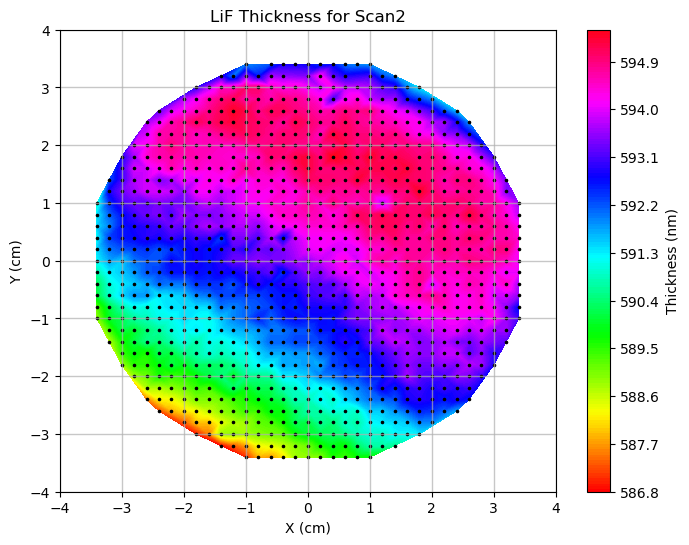

In [3]:
Scan2.Ron_plot()

That shows the aggregate thickness formed by summing the intelayer and the LiF layer. It appears that the basic shape is a slight quadratic ridge rather than the tilted plane of the last sample.

Here is the second version of this same orientation.

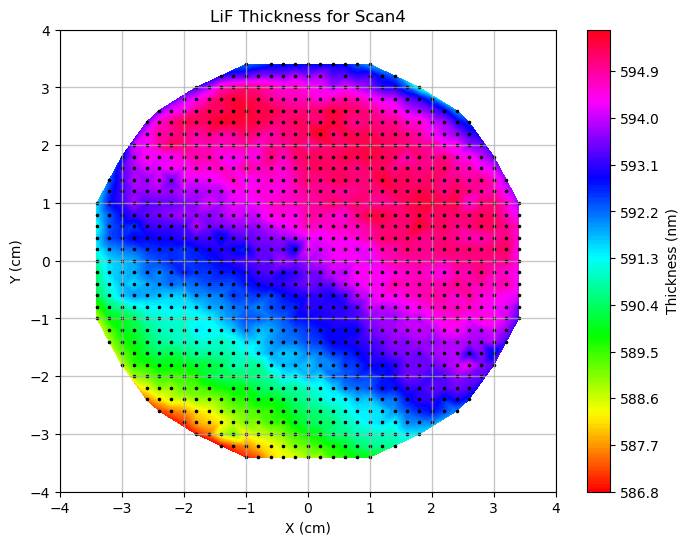

In [4]:
Scan4 = DepositData.from_file('Run6_26_Scan4.txt', 'Scan4')
Scan4.Ron_plot()

The consistency from scan to scan is very pleasing. Let's look at the rotated version.

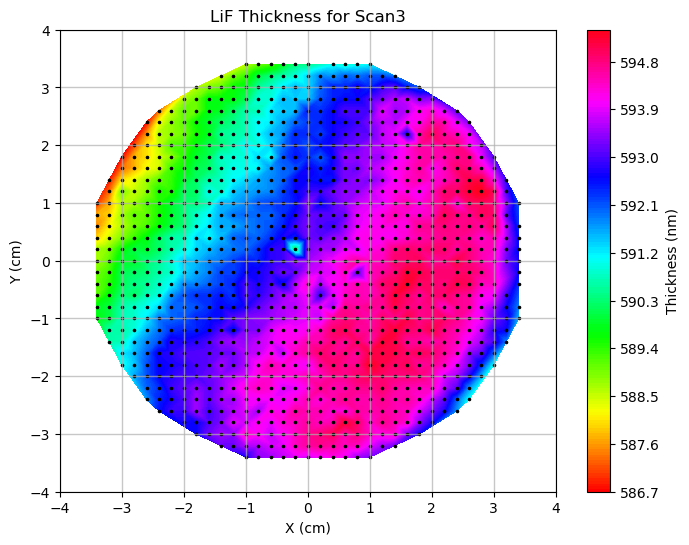

In [5]:
Scan3 = DepositData.from_file('Run6_26_Scan3.txt', 'Scan3')
Scan3.Ron_plot()

Well, it has indeed rotated 90° and there are several significant noise points present now that were not visible before but otherwise this looks just the same.

I wanted to plot differences but there are some missing points in the scans that make that non-trivial. To compute a difference will require point by point matching, preserving only the points that are in both scans. In the meantime let's see about fitting what we do have. I will work on Scan2 to start with.

First, let's note just how curved this surface is

![Scan2 heights](Run6_26_Scan2.png)

The curve is really large (about 8 nm) compared to the noise (about 1 nm).

We can do a moderately good job of fitting it with a quartic hump (a quadratic is too broad). I have added quadratic (angle_hump) and quartic (angled_ridge) fitting functions to the class.

First we bind the generic fitter to the angled_ridge function and set up initial params.

In [6]:
def ridge_fit(p, a):
    return DepositData.fit_helper(p, a, 'angled_ridge')

ip=[Scan2.avg_thickness, np.pi/2.2, -0.1, 0.001]

Then we can run the fit and print the result.

In [7]:
rr =Scan2.fit_to(ridge_fit, ip)
print(rr)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 194.40391404116872
        x: [ 5.935e+02  1.059e+00 -8.697e-01  2.958e-02]
      nit: 15
      jac: [ 0.000e+00  1.278e-04  4.196e-05  3.300e-04]
 hess_inv: [[ 7.145e-04  1.094e-04  4.957e-05  1.105e-05]
            [ 1.094e-04  6.707e-05  3.186e-05  5.588e-06]
            [ 4.957e-05  3.186e-05  3.289e-05  3.150e-06]
            [ 1.105e-05  5.588e-06  3.150e-06  5.708e-07]]
     nfev: 322
     njev: 62


Then we can plot the fit and the residuals.

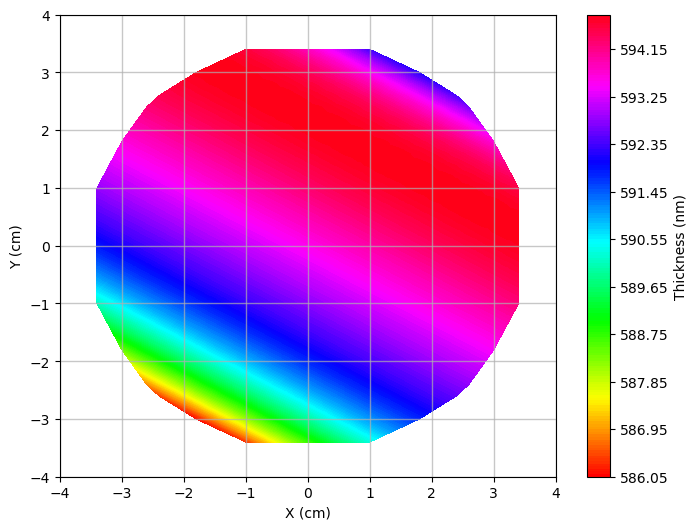

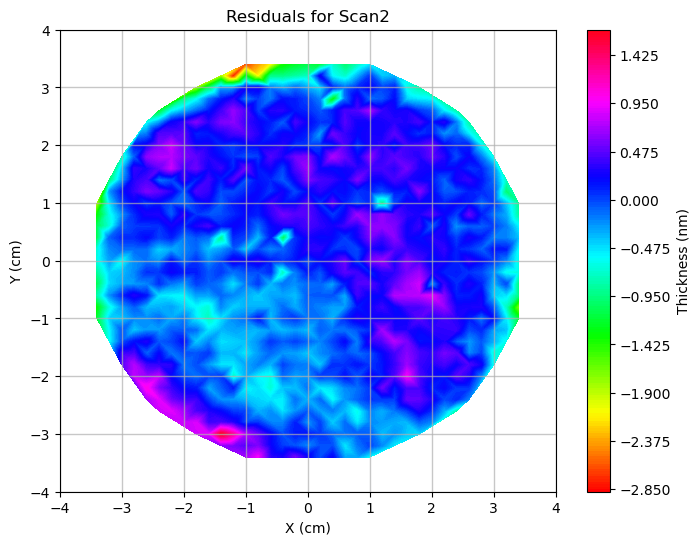

In [8]:
Scan2.contour_plot(Scan2.fit_z)
Scan2.resid_plot()

That leaves us with residuals that are mostly noise. There is a little bit of shape, possibly suggesting that we need both the quadratic and quartic terms, which is easy to test since I added a full even order quartic fitter.|

In [9]:
def quart_fit(p, a):
    return DepositData.fit_helper(p, a, 'angled_quartic')

ip5=[5.935e+02,  1.059e+00, -8.697e-01, 0.0,  2.958e-02]

In [10]:
rq =Scan2.fit_to(quart_fit, ip5)
print(rq)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 181.5670643228509
        x: [ 5.937e+02  1.053e+00 -8.698e-01  1.153e-01  1.860e-02]
      nit: 14
      jac: [ 0.000e+00  1.297e-04 -1.297e-04 -4.005e-05  6.294e-05]
 hess_inv: [[ 7.331e-04 -2.985e-06 ...  1.074e-05  9.054e-06]
            [-2.985e-06  1.069e-05 ...  2.361e-07 -2.530e-08]
            ...
            [ 1.074e-05  2.361e-07 ...  3.096e-06 -3.737e-07]
            [ 9.054e-06 -2.530e-08 ... -3.737e-07  5.543e-07]]
     nfev: 418
     njev: 68


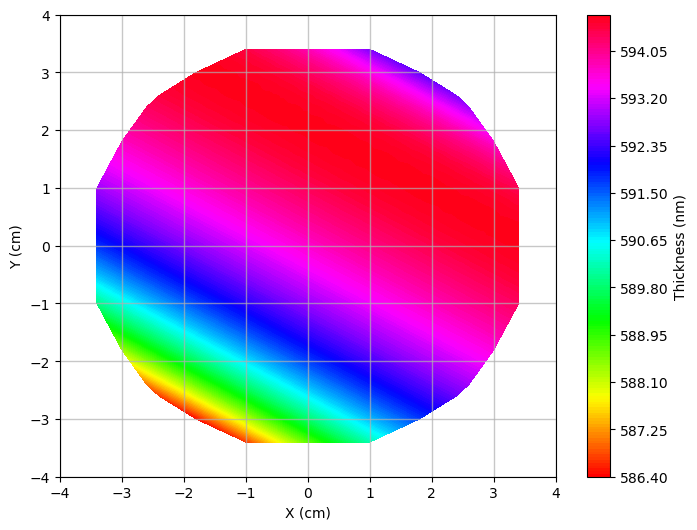

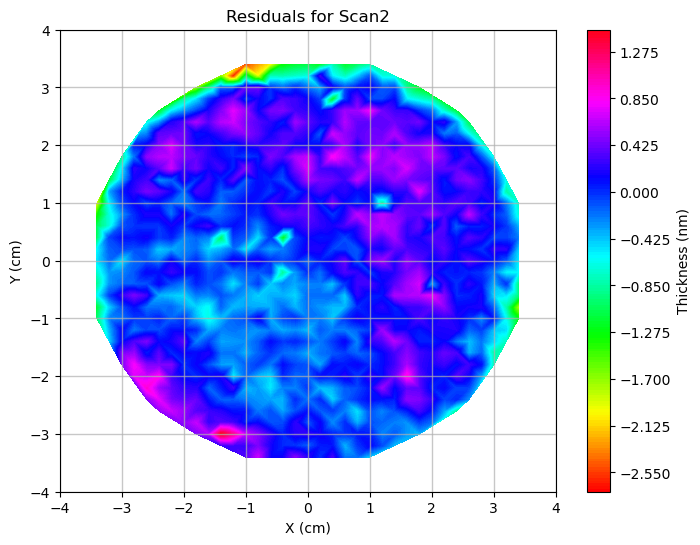

In [15]:
Scan2.contour_plot(Scan2.fit_z)
Scan2.resid_plot()

Well, it is a tiny bit better (chi_sq fell a few %) but not really different. Single point outliers show up more clearly now.

## Scan4

Let's repeat the analysis on Scan4 and see how close the parameters are. This time I omit the fit plot because it is really not interesting.

In [11]:
rq4 =Scan4.fit_to(quart_fit, ip5)
print(rq4)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 174.71335304509319
        x: [ 5.938e+02  1.045e+00 -9.325e-01  1.174e-01  1.869e-02]
      nit: 14
      jac: [-2.670e-05  2.670e-05 -1.183e-04  2.480e-05  8.659e-04]
 hess_inv: [[ 2.248e-02 -1.824e-02 ...  1.194e-02 -1.422e-03]
            [-1.824e-02  1.529e-02 ... -1.001e-02  1.202e-03]
            ...
            [ 1.194e-02 -1.001e-02 ...  6.554e-03 -7.873e-04]
            [-1.422e-03  1.202e-03 ... -7.873e-04  9.494e-05]]
     nfev: 272
     njev: 44


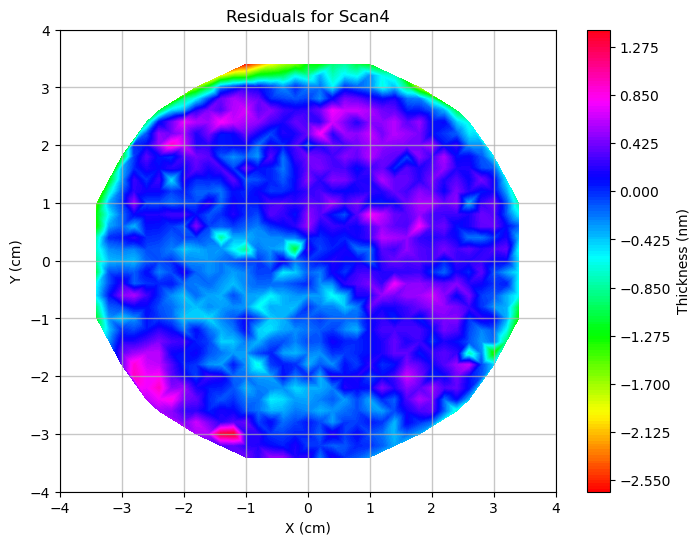

In [19]:
Scan4.resid_plot()

Very minor differences of detail. 

Let's look at the parameters.

In [12]:
print('Scan2', rq.x)
print('Scan4', rq4.x)
print('Diffs', rq.x - rq4.x)

Scan2 [ 5.93675558e+02  1.05292350e+00 -8.69791076e-01  1.15299454e-01
  1.86004583e-02]
Scan4 [ 5.93831303e+02  1.04506907e+00 -9.32511252e-01  1.17435121e-01
  1.86903268e-02]
Diffs [-1.55745131e-01  7.85443223e-03  6.27201756e-02 -2.13566705e-03
 -8.98685255e-05]


And casting the diffs as percentages

In [13]:
diffs = 100 * (rq.x - rq4.x) / rq.x
for d in diffs:
    print(f'{d:.2g}%')

-0.026%
0.75%
-7.2%
-1.9%
-0.48%


So all of those look good. The slight slope is the only one with any significant difference and it only contributes a small amount to the actual values.

## Scan3

So what about the rotated scan. We would expect a difference in angle this time!

In [14]:
ip3 = ip5
ip3[1] += np.pi/2 # Rotate 90°
rq3 =Scan3.fit_to(quart_fit, ip3)
print(rq3)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 193.51239916146432
        x: [ 5.934e+02 -5.287e-01 -9.023e-01  1.036e-01  1.912e-02]
      nit: 18
      jac: [-1.907e-06  2.022e-04  1.354e-04 -1.907e-06 -1.507e-04]
 hess_inv: [[ 2.397e-03 -5.764e-04 ...  1.249e-03 -1.067e-04]
            [-5.764e-04  2.027e-04 ... -4.198e-04  3.933e-05]
            ...
            [ 1.249e-03 -4.198e-04 ...  9.212e-04 -8.622e-05]
            [-1.067e-04  3.933e-05 ... -8.622e-05  8.590e-06]]
     nfev: 294
     njev: 47


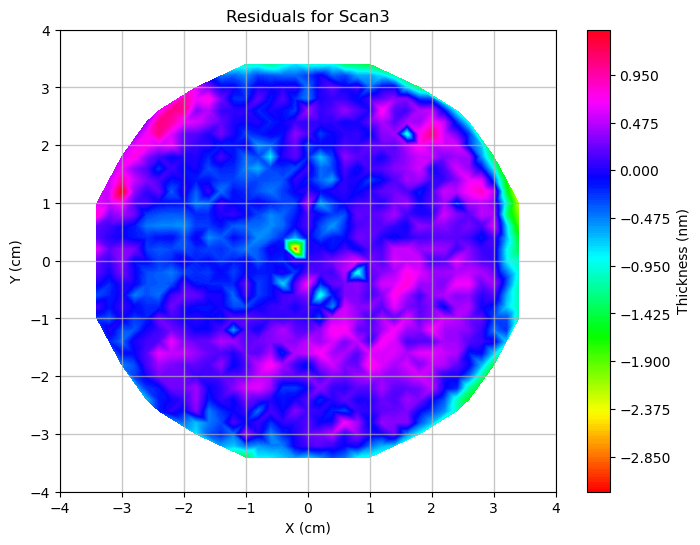

In [25]:
Scan3.resid_plot()

Oh look! The residuals have been rotated too! Doing our parameter analysis again.

In [15]:
print('Scan2', rq.x)
print('Scan3', rq3.x)
diffs23 = 100 * (rq.x - rq3.x) / rq.x
for d in diffs23:
    print(f'{d:.2g}%')

Scan2 [ 5.93675558e+02  1.05292350e+00 -8.69791076e-01  1.15299454e-01
  1.86004583e-02]
Scan3 [ 5.93436849e+02 -5.28749569e-01 -9.02316334e-01  1.03565307e-01
  1.91155495e-02]
0.04%
1.5e+02%
-3.7%
10%
-2.8%


Well, obviously the angle has changed a lot. Otherwise the changes are again not large. The 10% change in the quadratic term is the largest. Not sure what that means. There is that one really bad spot near the center of this pattern that may be responsible for much of the difference.

## Ellipsometry measurement difference

This one is not so easy to compute because there are different points missing in each scan. What I really want to do is to regularize each of the scans so that we can do direct comparisons. I think that scan2 may be complete. Let's check.

Text(0, 0.5, 'Y (cm)')

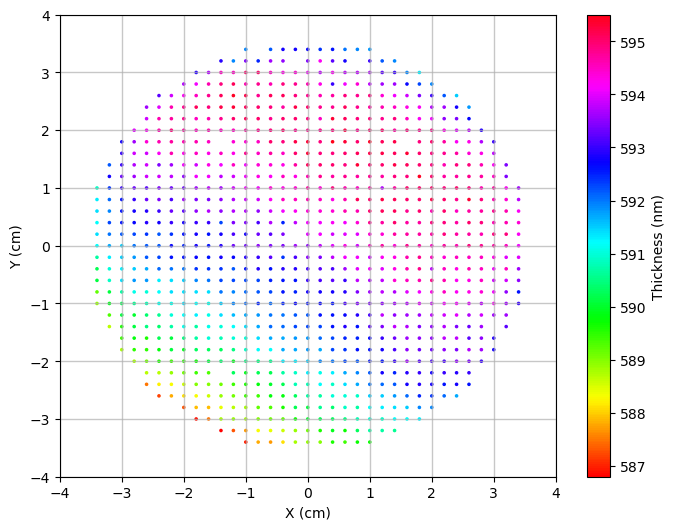

In [16]:
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(Scan2.xdata, Scan2.ydata, c=Scan2.zdata, marker='.', s=10, cmap='hsv')
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')


Nope. Let's try the others. Here's Scan3.

Text(0, 0.5, 'Y (cm)')

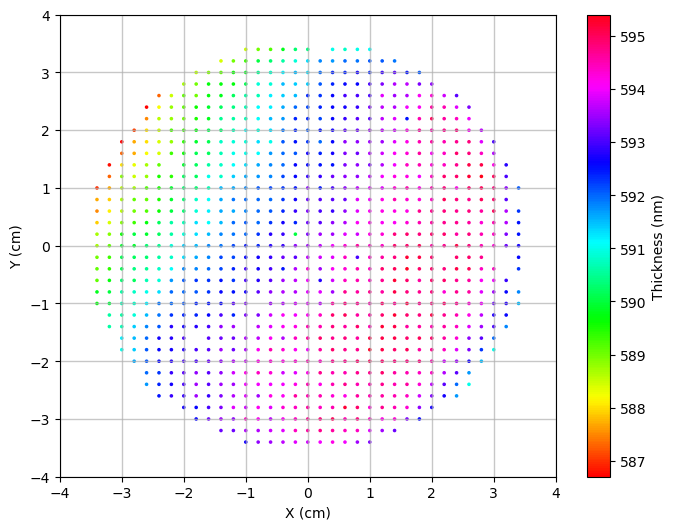

In [17]:
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(Scan3.xdata, Scan3.ydata, c=Scan3.zdata, marker='.', s=10, cmap='hsv')
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')


No better. And Scan4?

Text(0, 0.5, 'Y (cm)')

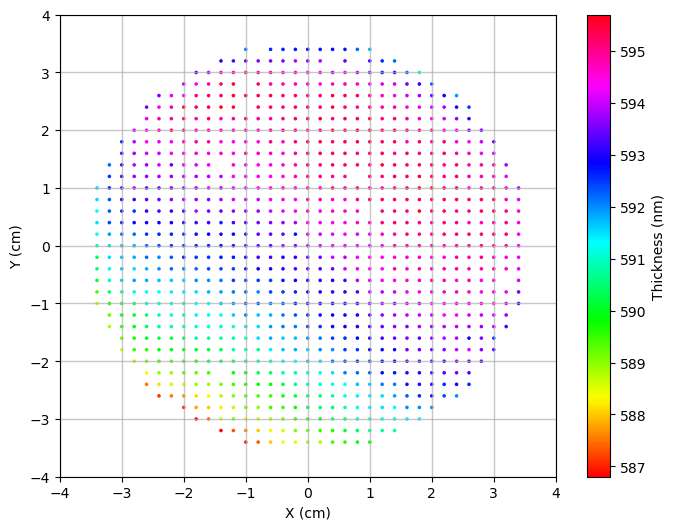

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(Scan4.xdata, Scan4.ydata, c=Scan4.zdata, marker='.', s=10, cmap='hsv')
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')


OK, so ALL of them have missing points. That is annoying. I guess that I can
work through the arrays element by element and keep only the common points, but that will be
quite tricky to maintain synchronization.

## A New Data Structure

Right, a little care shows me that the data are currently stored in a zig-zag fashion, starting at the top right and scanning to the left, then down and scan to the right, down and scan to the left, and so on. This makes finding anything IMPOSSIBLE. So I will switch to storing FULL square (extendable to rectangular if needed) grids with a mask showing which elements to use. I build my own full grids and then copy the data into them using the fact that for a regular grid I can compute the index of any point algorithmically from the coordinates. I am also making the t2, grding, roughness, and voidness arrays optional so that I will be able to construct data from e.g. the difference of two data sets, an operation that only makes sense for the height data.

After stupid typological and indexing problems that seems to work. Here is the new version of the Scan2 data.

In [18]:
from DepositData3 import DepositData3

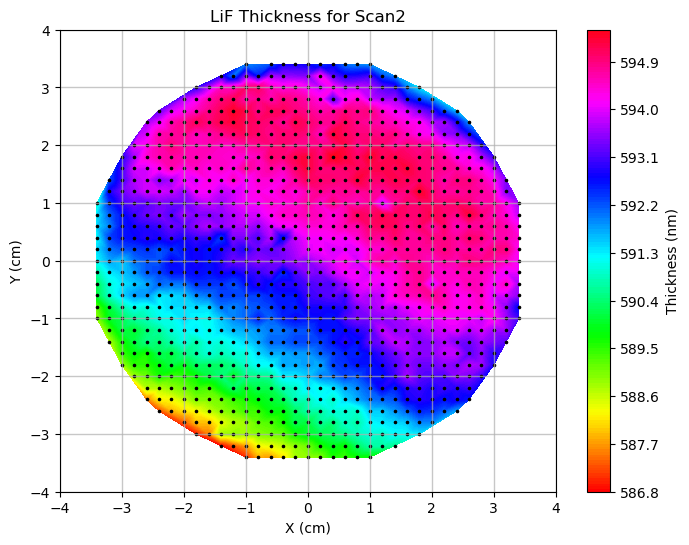

In [19]:
NScan2 = DepositData3.from_file('Run6_26_Scan2.txt', 'Scan2')
NScan2.Ron_plot()

And that looks just the same, even to the missing points. Let's pull in Scan4 too.

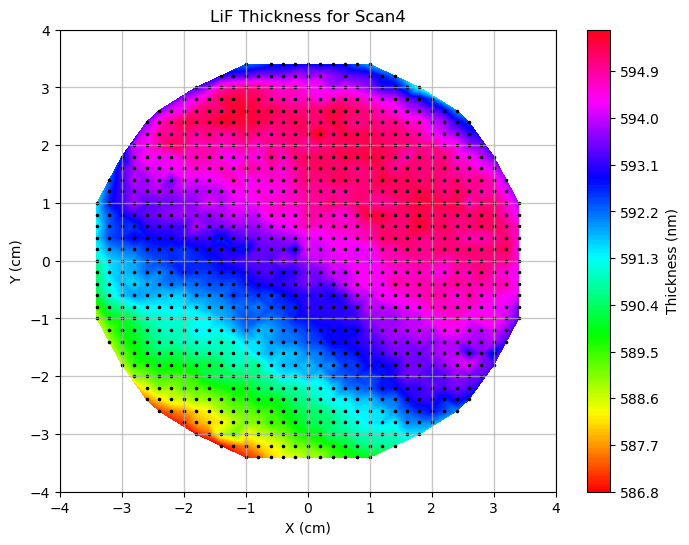

In [20]:
NScan4 = DepositData3.from_file('Run6_26_Scan4.txt', 'Scan4')
NScan4.Ron_plot()

Now we should be able to write a subtractor! I am going to play a bit, starting by forming the intersection of the two masks.

In [21]:
i_mask = np.logical_and(NScan2.mask, NScan4.mask)

Text(0, 0.5, 'Y (cm)')

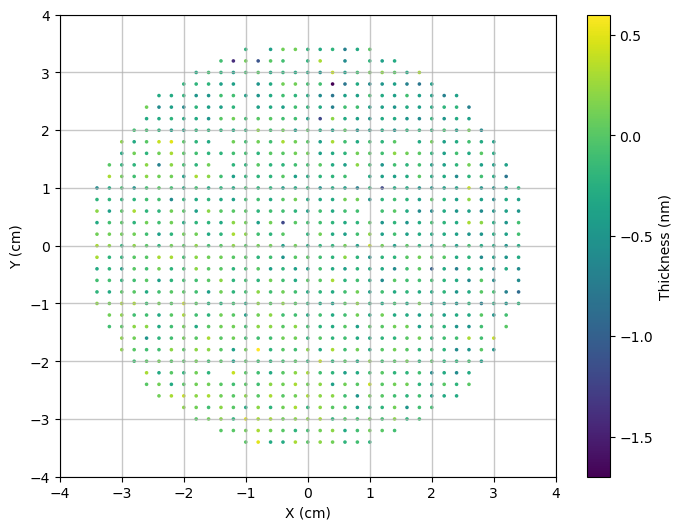

In [24]:
zdiff = NScan2.zdata - NScan4.zdata
fig, ax = plt.subplots(figsize=(8,6))
c = ax.scatter(NScan2.xdata[i_mask], NScan2.ydata[i_mask], c=zdiff[i_mask], marker='.', s=10)
plt.colorbar(c, label='Thickness (nm)')
plt.grid(True, linestyle='-', linewidth=1, alpha=0.7)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')


Oh wow! That is gorgeous. Let's do the histogram.

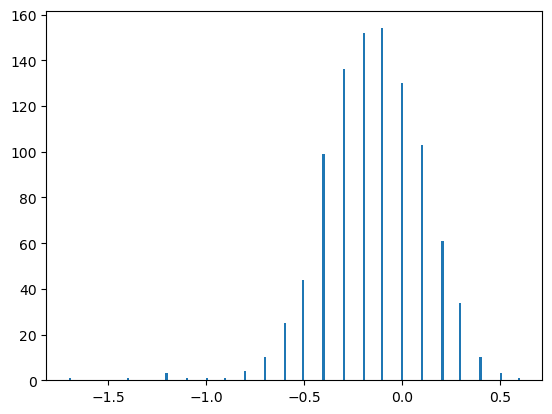

In [26]:
h1 = plt.hist(zdiff[i_mask], bins=201)

So, there is the repeatability noise in the Ellipsometry! Interestingly, there is a slight mean shift between the two measurements. FWHM is about 0.5 nm or about 0.1%.